# Compare Estimators Across Configurations (J, N, P)

This notebook analyzes PyMC/ArviZ traces for different experimental settings:
- **J**: Choice set size (100, 200, 500)
- **N**: Population size (10k, 20k)
- **P**: Number of parameters (10, 20, 40)

**Analysis includes:**
- ArviZ summary with 95% HDI for all parameters
- Coverage: proportion of true parameters inside 95% HDI
- Posterior MSE: mean squared error of posterior samples
- Interval width and relative width
- RMSE and MAE of posterior means vs true values

In [1]:
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Add parent directory to path for imports
sys.path.append('../gibbs_sampler')
from true_parameters import get_true_parameters

# Results directory
RESULTS_DIR = Path('../../results')
M=0
TRACE_DIR = RESULTS_DIR / 'results_pymc/full_C/p10/'

print(f'Results dir: {RESULTS_DIR}')
print(f'Trace dir: {TRACE_DIR}')
print(f'Trace dir exists: {TRACE_DIR.exists()}')

# display settings
pd.set_option('display.max_rows', 500)


Results dir: ../../results
Trace dir: ../../results/results_pymc/full_C/p10
Trace dir exists: True


In [3]:
# Load the two traces
path_old = "/Users/preto/Documents/EPFL/PhD/transp-or/likelihood_free/bayesian-sampled-choice-set/adaptive_sampler/output/trace_J100_N10000_P10_steps10000_SCALE.nc"
path_new = "/Users/preto/Documents/EPFL/PhD/projects/Bayesian/bayesian-choice-modeling-w-alt-sampling/results/results_pymc/timed_adaptive_sampler/trace_J100_N10000_P10_prot2_mtm_steps10000_SCALE_timed_260603.nc"

trace_old = az.from_netcdf(path_old)
trace_new = az.from_netcdf(path_new)

# Compare a key parameter (e.g., beta_rating)
var = "beta_rating"
diff = np.abs(trace_old.posterior[var].values - trace_new.posterior[var].values)

print(f"Max difference for {var}: {np.max(diff)}")
print(f"Are they identical? {np.allclose(trace_old.posterior[var].values, trace_new.posterior[var].values)}")

Max difference for beta_rating: 0.0
Are they identical? True


## 1. Find and Parse Trace Files

In [4]:
def parse_filename_config(fname):
    """Extract J, N, P, M from filename like restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_fullAV.nc or restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc"""
    s = str(fname)
    
    # Extract P, J, N in the order they appear: P{P}_J{J}_N{N}
    p_match = re.search(r'_P(\d+)', s)
    j_match = re.search(r'_J(\d+)', s)
    n_match = re.search(r'_N(\d+)k', s)
    m_match = re.search(r'_M(\d+)', s)
    
    if not (p_match and j_match and n_match):
        return None
    
    P = int(p_match.group(1))
    J = int(j_match.group(1))
    N = int(n_match.group(1)) * 1000  # Convert 10k -> 10000
    M = int(m_match.group(1)) if m_match else 0
    
    # Extract M (default to 0 if not found)
    m_match = re.search(r'_M(\d+)', s)
    
    return {
        'J': J,
        'N': N,
        'P': P,
        'M': M,
        'file': fname
    }

# Find all trace files
trace_files = sorted(TRACE_DIR.glob('restaurants_mnl_P*_J*_N*_M*.nc')) if TRACE_DIR.exists() else []
print(f'\nFound {len(trace_files)} trace files:')
for f in trace_files[:15]:
    cfg = parse_filename_config(f.name)
    if cfg:
        print(f"  {f.name} → J={cfg['J']}, N={cfg['N']}, P={cfg['P']}, M={cfg['M']}")
    else:
        print(f"  {f.name} → Could not parse")

if len(trace_files) > 15:
    print(f'  ... and {len(trace_files) - 15} more files')


Found 9 trace files:
  restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~01.nc → J=100, N=10000, P=10, M=0
  restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc → J=100, N=20000, P=10, M=0
  restaurants_mnl_P10_J100_N50k_I0_C0_M0_woJIT.nc → J=100, N=50000, P=10, M=0
  restaurants_mnl_P10_J200_N10k_I0_C0_M0_woJIT.nc → J=200, N=10000, P=10, M=0
  restaurants_mnl_P10_J200_N20k_I0_C0_M0_woJIT.nc → J=200, N=20000, P=10, M=0
  restaurants_mnl_P10_J200_N50k_I0_C0_M0_woJIT.nc → J=200, N=50000, P=10, M=0
  restaurants_mnl_P10_J500_N10k_I0_C0_M0_woJIT.nc → J=500, N=10000, P=10, M=0
  restaurants_mnl_P10_J500_N20k_I0_C0_M0_woJIT.nc → J=500, N=20000, P=10, M=0
  restaurants_mnl_P10_J500_N50k_I0_C0_M0_woJIT.nc → J=500, N=50000, P=10, M=0


## 2. Load Traces and Compute ArviZ Summary

For each trace file, we:
1. Load with `az.from_netcdf()`
2. Get true parameters for that P value
3. Compute `az.summary()` with 95% HDI

In [5]:
param_names={
    '10':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 ],
    '20':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 'beta_cost_x_logincome',
 'beta_logdist_x_age',
 'beta_rating_x_edu_sec',
 'beta_c_16',
 'beta_c_19',
 'beta_c_20',
 'beta_c_21',
 'beta_c_22',
 'beta_c_24',
 'beta_c_25',
 ],
    '40':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 'beta_cost_x_logincome',
 'beta_logdist_x_age',
 'beta_rating_x_edu_sec',
 'beta_c_16',
 'beta_c_19',
 'beta_c_20',
 'beta_c_21',
 'beta_c_22',
 'beta_c_24',
 'beta_c_25',
 'beta_c_26',
 'beta_c_27',
 'beta_c_29',
 'beta_c_30',
 'beta_c_32',
 'beta_c_33',
 'beta_c_34',
 'beta_c_35',
 'beta_d_36',
 'beta_d_37',
 'beta_d_38',
 'beta_d_39',
 'beta_d_41',
 'beta_d_42',
 'beta_d_43',
 'beta_d_44',
 'beta_d_45',
 'beta_d_46',
 'beta_d_49',
 'beta_d_50']
}

In [6]:
all_summaries = []
all_metrics = []
all_convergence = []

for nc_path in trace_files:
    cfg = parse_filename_config(nc_path.name)
    if cfg is None or cfg['P'] is None:
        print(f"Skipping {nc_path.name} (could not parse config)")
        continue
    
    J, N, P, M = cfg['J'], cfg['N'], cfg['P'], cfg['M']
    print(f"\nProcessing: J={J}, N={N}, P={P}, M={M} [{nc_path.name}]")
    
    try:
        # Load trace
        trace = az.from_netcdf(nc_path)
        
        # Get true parameters (using M parameter)
        true_params = get_true_parameters(P=P, M=M)
        # param_names = list(true_params.keys())
        
        # Compute ArviZ summary with 95% HDI
        summary = az.summary(trace, var_names=param_names[f'{P}'], stat_focus="mean", round_to=None)
        
        # Add config columns to summary
        summary['J'] = J
        summary['N'] = N
        summary['P'] = P
        summary['M'] = M
        summary['file'] = nc_path.name
        summary['parameter'] = summary.index
        summary = summary.reset_index(drop=True)
        
        all_summaries.append(summary)
        
        # Compute per-parameter metrics
        for param in param_names[f'{P}']:
            if param not in trace.posterior.data_vars:
                continue
            if M == 0:
                true_val = true_params[param]
            if M == 1:
                true_val = 0.4*true_params[param]
            
            # Get posterior samples (flatten all chains and draws)
            samples = trace.posterior[param].values.flatten()
            
            # Posterior mean and HDI from summary
            post_mean = summary[summary['parameter'] == param]['mean'].values[0]
            hdi_low = summary[summary['parameter'] == param]['hdi_3%'].values[0]
            hdi_high = summary[summary['parameter'] == param]['hdi_97%'].values[0]
            
            # Convergence diagnostics from summary
            rhat = summary[summary['parameter'] == param]['r_hat'].values[0] if 'r_hat' in summary.columns else np.nan
            ess_bulk = summary[summary['parameter'] == param]['ess_bulk'].values[0] if 'ess_bulk' in summary.columns else np.nan
            ess_tail = summary[summary['parameter'] == param]['ess_tail'].values[0] if 'ess_tail' in summary.columns else np.nan
            
            # Check coverage
            in_hdi = (true_val >= hdi_low) and (true_val <= hdi_high)
            
            # Interval width
            interval_width = hdi_high - hdi_low
            rel_width = interval_width / abs(true_val) if abs(true_val) > 0.001 else np.nan
            
            # Posterior MSE
            posterior_mse = np.mean((samples - true_val)**2)
            
            # Point estimate errors
            abs_error = abs(post_mean - true_val)
            sq_error = (post_mean - true_val)**2
            
            all_metrics.append({
                'J': J, 'N': N, 'P': P, 'M': M,
                'file': nc_path.name,
                'parameter': param,
                'true_value': true_val,
                'posterior_mean': post_mean,
                'hdi_low': hdi_low,
                'hdi_high': hdi_high,
                'in_hdi': in_hdi,
                'interval_width': interval_width,
                'relative_width': rel_width,
                'posterior_mse': posterior_mse,
                'abs_error': abs_error,
                'sq_error': sq_error,
                'r_hat': rhat,
                'ess_bulk': ess_bulk,
                'ess_tail': ess_tail
            })
        
        # Compute file-level convergence summary
        rhat_values = summary['r_hat'].values if 'r_hat' in summary.columns else []
        ess_bulk_values = summary['ess_bulk'].values if 'ess_bulk' in summary.columns else []
        ess_tail_values = summary['ess_tail'].values if 'ess_tail' in summary.columns else []
        
        if len(rhat_values) > 0:
            # Check convergence: R-hat should be < 1.01 (stricter) or < 1.05 (more lenient)
            n_rhat_good = np.sum(rhat_values < 1.01)
            n_rhat_ok = np.sum(rhat_values < 1.05)
            n_rhat_bad = np.sum(rhat_values >= 1.05)
            max_rhat = np.max(rhat_values)
            
            # ESS should be > 400 (bulk) and > 400 (tail) for reliable inference
            n_ess_bulk_good = np.sum(ess_bulk_values > 400) if len(ess_bulk_values) > 0 else 0
            n_ess_tail_good = np.sum(ess_tail_values > 400) if len(ess_tail_values) > 0 else 0
            min_ess_bulk = np.min(ess_bulk_values) if len(ess_bulk_values) > 0 else np.nan
            min_ess_tail = np.min(ess_tail_values) if len(ess_tail_values) > 0 else np.nan
            
            all_convergence.append({
                'J': J, 'N': N, 'P': P, 'M': M,
                'file': nc_path.name,
                'n_parameters': len(param_names[f'{P}']),
                'n_rhat_good': n_rhat_good,
                'n_rhat_ok': n_rhat_ok,
                'n_rhat_bad': n_rhat_bad,
                'max_rhat': max_rhat,
                'n_ess_bulk_good': n_ess_bulk_good,
                'n_ess_tail_good': n_ess_tail_good,
                'min_ess_bulk': min_ess_bulk,
                'min_ess_tail': min_ess_tail,
                'converged': (n_rhat_bad == 0) and (min_ess_bulk > 40) and (min_ess_tail > 40)
            })
            
            conv_status = "✓ CONVERGED" if all_convergence[-1]['converged'] else "⚠ CONVERGENCE ISSUES"
            print(f"  {conv_status}: max R-hat={max_rhat:.4f}, min ESS_bulk={min_ess_bulk:.0f}, min ESS_tail={min_ess_tail:.0f}")

        print(f"  ✓ Processed {len(param_names[f'{P}'])} parameters")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

print(f"\n{'='*70}")
print(f"Total summaries collected: {len(all_summaries)}")
print(f"Total parameter-level metrics: {len(all_metrics)}")
print(f"Total convergence summaries: {len(all_convergence)}")
print(f"{'='*70}")


Processing: J=100, N=10000, P=10, M=0 [restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~01.nc]
  ✓ CONVERGED: max R-hat=1.0100, min ESS_bulk=410, min ESS_tail=488
  ✓ Processed 10 parameters

Processing: J=100, N=20000, P=10, M=0 [restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc]
  ✓ CONVERGED: max R-hat=1.0100, min ESS_bulk=812, min ESS_tail=1045
  ✓ Processed 10 parameters

Processing: J=100, N=50000, P=10, M=0 [restaurants_mnl_P10_J100_N50k_I0_C0_M0_woJIT.nc]
  ✓ CONVERGED: max R-hat=1.0200, min ESS_bulk=290, min ESS_tail=544
  ✓ Processed 10 parameters

Processing: J=200, N=10000, P=10, M=0 [restaurants_mnl_P10_J200_N10k_I0_C0_M0_woJIT.nc]
  ✓ CONVERGED: max R-hat=1.0000, min ESS_bulk=753, min ESS_tail=1240
  ✓ Processed 10 parameters

Processing: J=200, N=20000, P=10, M=0 [restaurants_mnl_P10_J200_N20k_I0_C0_M0_woJIT.nc]
  ✓ CONVERGED: max R-hat=1.0100, min ESS_bulk=363, min ESS_tail=442
  ✓ Processed 10 parameters

Processing: J=200, N=50000, P=10, M=0 [restaurants_mnl_P10_J200_N50k_

## 3. Create DataFrames with All Results

**DataFrame 1**: All ArviZ summaries (posterior mean, sd, HDI, ess, rhat, etc.)  
**DataFrame 2**: All quality indicators (coverage, RMSE, MAE, posterior MSE, interval widths)

In [7]:

df_summaries = pd.concat(all_summaries, ignore_index=True)
print(f"DataFrame 1: All ArviZ summaries")
print(f"Shape: {df_summaries.shape}")
print(f"Columns: {list(df_summaries.columns)}")
display(df_summaries.head(50))

DataFrame 1: All ArviZ summaries
Shape: (90, 15)
Columns: ['mean', 'sd', 'hdi_3%', 'hdi_97%', 'mcse_mean', 'mcse_sd', 'ess_bulk', 'ess_tail', 'r_hat', 'J', 'N', 'P', 'M', 'file', 'parameter']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,J,N,P,M,file,parameter
0,0.755,0.022,0.712,0.794,0.001,0.001,1392.0,1250.0,1.00,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_rating
1,-0.405,0.004,-0.412,-0.397,0.000,0.000,1152.0,1291.0,1.00,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_cost
2,-0.582,0.015,-0.608,-0.554,0.000,0.000,1268.0,1098.0,1.00,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_log_dist
3,0.856,0.059,0.742,0.964,0.003,0.002,440.0,777.0,1.01,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_chinese
4,1.317,0.056,1.213,1.420,0.003,0.002,410.0,607.0,1.01,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_japanese
5,0.862,0.064,0.731,0.974,0.003,0.002,532.0,682.0,1.01,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_korean
6,0.984,0.080,0.830,1.129,0.003,0.002,691.0,1078.0,1.00,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_indian
7,0.901,0.060,0.801,1.023,0.003,0.002,458.0,488.0,1.01,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_french
8,1.351,0.058,1.255,1.471,0.003,0.002,467.0,800.0,1.00,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_mexican
9,0.897,0.060,0.782,1.005,0.003,0.002,503.0,809.0,1.01,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_lebanese


In [8]:

df_metrics = pd.DataFrame(all_metrics)
print(f"\nDataFrame 2: All quality indicators")
print(f"Shape: {df_metrics.shape}")
print(f"Columns: {list(df_metrics.columns)}")
display(df_metrics)


DataFrame 2: All quality indicators
Shape: (90, 19)
Columns: ['J', 'N', 'P', 'M', 'file', 'parameter', 'true_value', 'posterior_mean', 'hdi_low', 'hdi_high', 'in_hdi', 'interval_width', 'relative_width', 'posterior_mse', 'abs_error', 'sq_error', 'r_hat', 'ess_bulk', 'ess_tail']


,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
0,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_rating,0.75,0.755,0.712,0.794,True,0.082,0.109333,0.000491,0.005,2.500000e-05,1.00,1392.0,1250.0
1,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_cost,-0.40,-0.405,-0.412,-0.397,True,0.015,0.037500,0.000038,0.005,2.500000e-05,1.00,1152.0,1291.0
2,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_log_dist,-0.60,-0.582,-0.608,-0.554,True,0.054,0.090000,0.000534,0.018,3.240000e-04,1.00,1268.0,1098.0
3,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_chinese,0.83,0.856,0.742,0.964,True,0.222,0.267470,0.004181,0.026,6.760000e-04,1.01,440.0,777.0
4,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_japanese,1.25,1.317,1.213,1.420,True,0.207,0.165600,0.007673,0.067,4.489000e-03,1.01,410.0,607.0
5,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_korean,0.75,0.862,0.731,0.974,True,0.243,0.324000,0.016660,0.112,1.254400e-02,1.01,532.0,682.0
6,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_indian,1.00,0.984,0.830,1.129,True,0.299,0.299000,0.006592,0.016,2.560000e-04,1.00,691.0,1078.0
7,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_french,0.95,0.901,0.801,1.023,True,0.222,0.233684,0.005962,0.049,2.401000e-03,1.01,458.0,488.0
8,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_mexican,1.30,1.351,1.255,1.471,True,0.216,0.166154,0.005916,0.051,2.601000e-03,1.00,467.0,800.0
9,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT~0...,beta_lebanese,0.90,0.897,0.782,1.005,True,0.223,0.247778,0.003588,0.003,9.000000e-06,1.01,503.0,809.0


## Alternative: Load Existing Metrics and Add Only New Traces

This approach is much faster when you already have processed most traces and only need to add a few new ones.

In [13]:
# Load existing metrics CSV
existing_metrics_path = RESULTS_DIR / 'biogeme_BI_m0_parameter_metrics.csv'

if existing_metrics_path.exists():
    df_existing = pd.read_csv(existing_metrics_path)
    print(f"✓ Loaded existing metrics: {df_existing.shape}")
    print(f"  Columns: {list(df_existing.columns)}")
    
    # Get list of already processed files
    processed_files = set(df_existing['file'].unique())
    print(f"  Already processed: {len(processed_files)} files")
    
    # Find new traces that haven't been processed yet
    all_trace_files = sorted(TRACE_DIR.glob('restaurants_mnl_P*_J*_N*_M*.nc')) if TRACE_DIR.exists() else []
    new_trace_files = [f for f in all_trace_files if f.name not in processed_files]
    
    print(f"\n📋 Found {len(new_trace_files)} NEW trace files to process:")
    for f in new_trace_files:
        cfg = parse_filename_config(f.name)
        if cfg:
            print(f"  {f.name} → J={cfg['J']}, N={cfg['N']}, P={cfg['P']}, M={cfg['M']}")
    
    if len(new_trace_files) == 0:
        print("\n✓ All traces already processed! Using existing metrics.")
        df_metrics = df_existing
    else:
        # Process only new traces
        print(f"\n{'='*70}")
        print(f"Processing {len(new_trace_files)} new traces...")
        print(f"{'='*70}")
        
        new_metrics = []
        
        for nc_path in new_trace_files:
            cfg = parse_filename_config(nc_path.name)
            if cfg is None or cfg['P'] is None:
                print(f"Skipping {nc_path.name} (could not parse config)")
                continue
            
            J, N, P, M = cfg['J'], cfg['N'], cfg['P'], cfg['M']
            print(f"\nProcessing: J={J}, N={N}, P={P}, M={M} [{nc_path.name}]")
            
            try:
                # Load trace
                trace = az.from_netcdf(nc_path)
                
                # Get true parameters
                true_params = get_true_parameters(P=P, M=M)
                
                # Compute ArviZ summary
                # summary = az.summary(trace, var_names=param_names[f'{P}'], hdi_prob=0.95, stat_focus="mean", round_to=None)
                # --- FIX B: attach readable names to beta vector ---
                names = list(param_names[f"{P}"])
                
                # Make sure beta exists
                if "beta" not in trace.posterior.data_vars:
                    raise ValueError(f"'beta' not found. Posterior variables are: {list(trace.posterior.data_vars)}")
                
                # Identify the beta dimension (not chain or draw)
                beta_dim = [d for d in trace.posterior["beta"].dims 
                            if d not in ("chain", "draw")][0]
                
                # Assign parameter names as coordinates
                trace.posterior = trace.posterior.assign_coords({beta_dim: names})
                
                # Compute summary
                summary = az.summary(trace, var_names=["beta"], 
                                     hdi_prob=0.95, stat_focus="mean", round_to=None)
                
                beta = trace.posterior["beta"]

                for param in names:
                    
                    # Extract samples by coordinate label
                    samples = beta.sel({beta_dim: param}).values.flatten()
                    
                    if M == 0:
                        true_val = true_params[param]
                    if M == 1:
                        true_val = 0.4 * true_params[param]
                    
                    # Posterior mean and HDI from summary
                    row_label = f"beta[{param}]"
                    
                    post_mean = summary.loc[row_label, "mean"]
                    hdi_low = summary.loc[row_label, "hdi_2.5%"]
                    hdi_high = summary.loc[row_label, "hdi_97.5%"]
                    
                    # Convergence diagnostics
                    rhat = summary.loc[row_label, 'r_hat'] if 'r_hat' in summary.columns else np.nan
                    ess_bulk = summary.loc[row_label, 'ess_bulk'] if 'ess_bulk' in summary.columns else np.nan
                    ess_tail = summary.loc[row_label, 'ess_tail'] if 'ess_tail' in summary.columns else np.nan
                    
                    # Check coverage
                    in_hdi = (true_val >= hdi_low) and (true_val <= hdi_high)
                    
                    # Interval width
                    interval_width = hdi_high - hdi_low
                    rel_width = interval_width / abs(true_val) if abs(true_val) > 0.001 else np.nan
                    
                    # Posterior MSE
                    posterior_mse = np.mean((samples - true_val)**2)
                    
                    # Point estimate errors
                    abs_error = abs(post_mean - true_val)
                    sq_error = (post_mean - true_val)**2
                    
                    new_metrics.append({
                        'J': J, 'N': N, 'P': P, 'M': M,
                        'file': nc_path.name,
                        'parameter': param,
                        'true_value': true_val,
                        'posterior_mean': post_mean,
                        'hdi_low': hdi_low,
                        'hdi_high': hdi_high,
                        'in_hdi': in_hdi,
                        'interval_width': interval_width,
                        'relative_width': rel_width,
                        'posterior_mse': posterior_mse,
                        'abs_error': abs_error,
                        'sq_error': sq_error,
                        'r_hat': rhat,
                        'ess_bulk': ess_bulk,
                        'ess_tail': ess_tail
                    })
                
                print(f"  ✓ Processed {len(param_names[f'{P}'])} parameters")
                
            except Exception as e:
                print(f"  ✗ Error: {e}")
                continue
        
        # Combine with existing metrics
        if new_metrics:
            df_new = pd.DataFrame(new_metrics)
            df_metrics = pd.concat([df_existing, df_new], ignore_index=True)
            
            # Save updated metrics
            df_metrics.to_csv(existing_metrics_path, index=False)
            print(f"\n✓ Added {len(df_new)} new parameter metrics")
            print(f"✓ Total metrics now: {len(df_metrics)}")
            print(f"✓ Saved to: {existing_metrics_path}")
        else:
            df_metrics = df_existing
            print("\n⚠ No new metrics were added")
else:
    print(f"⚠ File not found: {existing_metrics_path}")
    print("Please run the full processing above first, or check the file path.")
    df_metrics = pd.DataFrame()

print("\n" + "="*80)
print(f"Final df_metrics shape: {df_metrics.shape}")
print("="*80)
display(df_metrics.tail(20))

✓ Loaded existing metrics: (520, 19)
  Columns: ['J', 'N', 'P', 'M', 'file', 'parameter', 'true_value', 'posterior_mean', 'hdi_low', 'hdi_high', 'in_hdi', 'interval_width', 'relative_width', 'posterior_mse', 'abs_error', 'sq_error', 'r_hat', 'ess_bulk', 'ess_tail']
  Already processed: 23 files

📋 Found 4 NEW trace files to process:
  restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_2.nc → J=100, N=10000, P=10, M=0
  restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_fullAV.nc → J=100, N=10000, P=10, M=0
  restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_fullAV.nc → J=100, N=10000, P=40, M=0
  restaurants_mnl_P40_J200_N50k_I0_C0_M0_woJIT.nc → J=200, N=50000, P=40, M=0

Processing 4 new traces...

Processing: J=100, N=10000, P=10, M=0 [restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_2.nc]
  ✗ Error: 'Unable to synchronously open object (addr overflow, addr = 302146584, size = 80, eoa = 302146349)'

Processing: J=100, N=10000, P=10, M=0 [restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_fullAV.nc]
  ✓ Process

,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
550,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_26,0.16,0.229,0.170,0.289,False,0.119,0.743750,0.005680,0.069,0.004761,1.0,9680.0,11713.0
551,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_27,0.32,0.440,0.097,0.784,True,0.687,2.146875,0.045194,0.120,0.014400,1.0,11002.0,12210.0
552,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_29,0.24,-0.137,-0.182,-0.094,False,0.088,0.366667,0.142293,0.377,0.142129,1.0,17257.0,12904.0
553,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_30,0.26,0.244,0.098,0.391,True,0.293,1.126923,0.005854,0.016,0.000256,1.0,10565.0,12402.0
554,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_32,0.20,0.375,0.232,0.523,False,0.291,1.455000,0.036212,0.175,0.030625,1.0,11340.0,12343.0
555,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_33,0.30,0.326,0.224,0.430,True,0.206,0.686667,0.003499,0.026,0.000676,1.0,11879.0,12855.0
556,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_34,-0.15,-0.144,-0.235,-0.052,True,0.183,1.220000,0.002207,0.006,0.000036,1.0,8009.0,10897.0
557,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_c_35,0.34,0.223,0.127,0.321,False,0.194,0.570588,0.016235,0.117,0.013689,1.0,11416.0,12954.0
558,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_d_36,0.24,0.233,0.132,0.331,True,0.199,0.829167,0.002666,0.007,0.000049,1.0,13644.0,12594.0
559,100,10000,40,0,restaurants_mnl_P40_J100_N10k_I0_C0_M0_woJIT_f...,beta_d_37,0.28,-0.089,-0.170,-0.007,False,0.163,0.582143,0.138061,0.369,0.136161,1.0,15243.0,12241.0


In [11]:
df_new

,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
0,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_rating,0.75,0.755,0.716,0.796,True,0.080,0.106667,0.000450,0.005,0.000025,1.0,10971.0,11295.0
1,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_cost,-0.40,-0.404,-0.413,-0.397,True,0.016,0.040000,0.000036,0.004,0.000016,1.0,14451.0,11737.0
2,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_log_dist,-0.60,0.855,0.740,0.971,False,0.231,0.385000,2.119888,1.455,2.117025,1.0,4358.0,6558.0
3,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_chinese,0.83,1.316,1.202,1.421,False,0.219,0.263855,0.239221,0.486,0.236196,1.0,4127.0,5995.0
4,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_japanese,1.25,0.861,0.735,0.986,False,0.251,0.200800,0.155739,0.389,0.151321,1.0,5284.0,8236.0
5,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_korean,0.75,0.979,0.829,1.142,False,0.313,0.417333,0.058935,0.229,0.052441,1.0,5909.0,8818.0
6,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_indian,1.00,0.899,0.780,1.013,True,0.233,0.233000,0.013723,0.101,0.010201,1.0,4628.0,7253.0
7,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_french,0.95,1.350,1.235,1.464,False,0.229,0.241053,0.163116,0.400,0.160000,1.0,4571.0,7167.0
8,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_mexican,1.30,0.895,0.775,1.012,False,0.237,0.182308,0.167438,0.405,0.164025,1.0,4740.0,6659.0
9,100,10000,10,0,restaurants_mnl_P10_J100_N10k_I0_C0_M0_woJIT_f...,beta_lebanese,0.90,-0.581,-0.610,-0.552,False,0.058,0.064444,2.194169,1.481,2.193361,1.0,12189.0,9441.0


In [9]:
#J,N, P 500	20000	20
df_metrics[(df_metrics['J']==100) & (df_metrics['N']==10000) & (df_metrics['P']==10)].sort_values(by='r_hat', ascending=False)

,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail


In [16]:
# sort by r_hat descending
df_metrics[df_metrics['parameter']=='beta_cost'].sort_values(by='r_hat', ascending=False)


,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
1,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.398,-0.404,-0.393,True,0.011,0.0275,0.000011,0.002,0.000004,1.0,2972.0,2800.0
161,200,20000,20,0,restaurants_mnl_P20_J200_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.384,-0.421,-0.350,True,0.071,0.1775,0.000598,0.016,0.000256,1.0,1403.0,1365.0
441,500,10000,40,0,restaurants_mnl_P40_J500_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.383,-0.426,-0.334,True,0.092,0.2300,0.000842,0.017,0.000289,1.0,2062.0,1204.0
401,200,20000,40,0,restaurants_mnl_P40_J200_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.417,-0.454,-0.379,True,0.075,0.1875,0.000663,0.017,0.000289,1.0,1876.0,1303.0
361,200,10000,40,0,restaurants_mnl_P40_J200_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.465,-0.520,-0.414,False,0.106,0.2650,0.005028,0.065,0.004225,1.0,8372.0,5981.0
321,100,50000,40,0,restaurants_mnl_P40_J100_N50k_I0_C0_M0_woJIT~0...,beta_cost,-0.4,-0.383,-0.407,-0.361,True,0.046,0.1150,0.000436,0.017,0.000289,1.0,2085.0,1113.0
281,100,50000,40,0,restaurants_mnl_P40_J100_N50k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.383,-0.404,-0.361,True,0.043,0.1075,0.000424,0.017,0.000289,1.0,1967.0,1680.0
241,100,20000,40,0,restaurants_mnl_P40_J100_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.405,-0.439,-0.370,True,0.069,0.1725,0.000326,0.005,0.000025,1.0,3605.0,3173.0
221,500,20000,20,0,restaurants_mnl_P20_J500_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.382,-0.414,-0.351,True,0.063,0.1575,0.000599,0.018,0.000324,1.0,1638.0,1048.0
201,500,10000,20,0,restaurants_mnl_P20_J500_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.391,-0.435,-0.344,True,0.091,0.2275,0.000612,0.009,0.000081,1.0,1446.0,1263.0


In [9]:
df_metrics.to_csv(RESULTS_DIR / 'biogeme_BI_m0_parameter_metrics_96_p10.csv', index=False)


<div class="alert alert-info">

**curse of dimensionality in MCMC ?**

when P increases, sampling quality degrades (higher r_hat, lower ess)
| Hypothesis                     | Supported? | Explanation                                 |
| ------------------------------ | ---------- | ------------------------------------------- |
| Global curse of dimensionality | ❌          | Most parameters mix fine; ESS high.         |
| Local correlation problem      | ✅          | Only cost-related parameters are stuck.     |
| Model mis-identification       | ❌          | Posteriors still centered near true values. |




</div>

In [18]:
beta_cost_df= df_metrics[df_metrics['parameter']=='beta_cost'] 
#re order per P
beta_cost_df = beta_cost_df.sort_values(by=['P'])
display(beta_cost_df)


,J,N,P,M,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
1,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.398,-0.404,-0.393,True,0.011,0.0275,0.000011,0.002,0.000004,1.0,2972.0,2800.0
11,100,50000,10,0,restaurants_mnl_P10_J100_N50k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.399,-0.403,-0.396,True,0.007,0.0175,0.000004,0.001,0.000001,1.0,1954.0,1666.0
21,200,10000,10,0,restaurants_mnl_P10_J200_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.395,-0.402,-0.388,True,0.014,0.0350,0.000039,0.005,0.000025,1.0,3036.0,2596.0
31,200,20000,10,0,restaurants_mnl_P10_J200_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.396,-0.401,-0.391,True,0.010,0.0250,0.000021,0.004,0.000016,1.0,1521.0,1344.0
41,200,50000,10,0,restaurants_mnl_P10_J200_N50k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.398,-0.402,-0.395,True,0.007,0.0175,0.000005,0.002,0.000004,1.0,1775.0,1408.0
51,500,10000,10,0,restaurants_mnl_P10_J500_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.402,-0.410,-0.395,True,0.015,0.0375,0.000018,0.002,0.000004,1.0,1705.0,1544.0
61,500,20000,10,0,restaurants_mnl_P10_J500_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.400,-0.404,-0.395,True,0.009,0.0225,0.000006,0.000,0.000000,1.0,1816.0,1368.0
71,500,50000,10,0,restaurants_mnl_P10_J500_N50k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.401,-0.404,-0.398,True,0.006,0.0150,0.000003,0.001,0.000001,1.0,1977.0,1655.0
221,500,20000,20,0,restaurants_mnl_P20_J500_N20k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.382,-0.414,-0.351,True,0.063,0.1575,0.000599,0.018,0.000324,1.0,1638.0,1048.0
201,500,10000,20,0,restaurants_mnl_P20_J500_N10k_I0_C0_M0_woJIT.nc,beta_cost,-0.4,-0.391,-0.435,-0.344,True,0.091,0.2275,0.000612,0.009,0.000081,1.0,1446.0,1263.0


In [19]:
# DataFrame 3: Convergence diagnostics by file
if all_convergence:
    df_convergence = pd.DataFrame(all_convergence)
    print(f"\nDataFrame 3: Convergence diagnostics")
    print(f"Shape: {df_convergence.shape}")
    print(f"Columns: {list(df_convergence.columns)}")
    print("\n" + "="*80)
    print("CONVERGENCE SUMMARY")
    print("="*80)
    display(df_convergence.sort_values(['P', 'J', 'N']))
    
    # Quick summary
    n_converged = df_convergence['converged'].sum()
    n_total = len(df_convergence)
    print(f"\n✓ Converged: {n_converged}/{n_total} ({n_converged/n_total*100:.1f}%)")
    
    if n_converged < n_total:
        print(f"\n⚠ Files with convergence issues:")
        issues = df_convergence[~df_convergence['converged']]
        for _, row in issues.iterrows():
            print(f"  - {row['file']}: max R-hat={row['max_rhat']:.4f}, min ESS_bulk={row['min_ess_bulk']:.0f}")
else:
    print("No convergence diagnostics available")
    df_convergence = pd.DataFrame()


DataFrame 3: Convergence diagnostics
Shape: (23, 15)
Columns: ['J', 'N', 'P', 'M', 'file', 'n_parameters', 'n_rhat_good', 'n_rhat_ok', 'n_rhat_bad', 'max_rhat', 'n_ess_bulk_good', 'n_ess_tail_good', 'min_ess_bulk', 'min_ess_tail', 'converged']

CONVERGENCE SUMMARY


,J,N,P,M,file,n_parameters,n_rhat_good,n_rhat_ok,n_rhat_bad,max_rhat,n_ess_bulk_good,n_ess_tail_good,min_ess_bulk,min_ess_tail,converged
0,100,20000,10,0,restaurants_mnl_P10_J100_N20k_I0_C0_M0_woJIT.nc,10,4,10,0,1.01,10,10,812.0,1045.0,True
1,100,50000,10,0,restaurants_mnl_P10_J100_N50k_I0_C0_M0_woJIT.nc,10,3,10,0,1.02,4,10,290.0,544.0,True
2,200,10000,10,0,restaurants_mnl_P10_J200_N10k_I0_C0_M0_woJIT.nc,10,10,10,0,1.00,10,10,753.0,1240.0,True
3,200,20000,10,0,restaurants_mnl_P10_J200_N20k_I0_C0_M0_woJIT.nc,10,9,10,0,1.01,6,10,363.0,442.0,True
4,200,50000,10,0,restaurants_mnl_P10_J200_N50k_I0_C0_M0_woJIT.nc,10,3,10,0,1.01,9,10,400.0,627.0,True
5,500,10000,10,0,restaurants_mnl_P10_J500_N10k_I0_C0_M0_woJIT.nc,10,8,10,0,1.01,10,10,477.0,743.0,True
6,500,20000,10,0,restaurants_mnl_P10_J500_N20k_I0_C0_M0_woJIT.nc,10,3,10,0,1.01,7,10,359.0,459.0,True
7,500,50000,10,0,restaurants_mnl_P10_J500_N50k_I0_C0_M0_woJIT.nc,10,3,10,0,1.02,7,10,361.0,530.0,True
8,100,10000,20,0,restaurants_mnl_P20_J100_N10k_I0_C0_M0_woJIT.nc,20,20,20,0,1.00,20,20,2779.0,4184.0,True
9,100,20000,20,0,restaurants_mnl_P20_J100_N20k_I0_C0_M0_woJIT.nc,20,20,20,0,1.00,20,20,1249.0,2018.0,True



✓ Converged: 23/23 (100.0%)


## 4. Aggregate Indicators by Configuration (J, N, P, M)

Compute aggregated metrics for each configuration:
- **Coverage**: proportion of parameters where true value is in 95% HDI
- **Mean interval width**: average HDI width
- **Mean relative width**: average HDI width / |true value|
- **RMSE**: root mean squared error of posterior means
- **MAE**: mean absolute error of posterior means
- **Mean posterior MSE**: average posterior MSE across parameters

In [ ]:
if not df_metrics.empty:
    agg = df_metrics.groupby(['J', 'N', 'P', 'M']).agg({
        'in_hdi': 'mean',
        'interval_width': 'mean',
        'relative_width': lambda x: np.nanmean(x),
        'posterior_mse': 'mean',
        'abs_error': 'mean',
        'sq_error': lambda x: np.sqrt(np.mean(x)),  # RMSE
        'r_hat': ['mean', 'max'],
        'ess_bulk': ['mean', 'min'],
        'ess_tail': ['mean', 'min'],
        'parameter': 'count'
    })
    
    # Flatten multi-level columns
    agg.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in agg.columns.values]
    agg = agg.reset_index()
    
    # Rename columns based on actual flattened names
    agg = agg.rename(columns={
        'in_hdi_mean': 'coverage',
        'interval_width_mean': 'mean_interval_width',
        'relative_width_<lambda>': 'mean_relative_width',
        'posterior_mse_mean': 'mean_posterior_mse',
        'abs_error_mean': 'mae',
        'sq_error_<lambda>': 'rmse',
        'r_hat_mean': 'mean_rhat',
        'r_hat_max': 'max_rhat',
        'ess_bulk_mean': 'mean_ess_bulk',
        'ess_bulk_min': 'min_ess_bulk',
        'ess_tail_mean': 'mean_ess_tail',
        'ess_tail_min': 'min_ess_tail',
        'parameter_count': 'n_parameters'
    })
    
    agg['coverage_pct'] = agg['coverage'] * 100
    
    # Add convergence flag: converged if max_rhat < 1.05 and min ESS > 400
    agg['converged'] = (agg['max_rhat'] < 1.05) & (agg['min_ess_bulk'] > 400) & (agg['min_ess_tail'] > 400)
    
    print("\n" + "="*80)
    print("AGGREGATED INDICATORS BY CONFIGURATION")
    print("="*80)
    display(agg.sort_values(['P', 'J', 'N']))
    
    # Save to CSV
    out_csv = RESULTS_DIR / 'aggregated_indicators_by_config.csv'
    # agg.to_csv(out_csv, index=False)
    print(f"\n✓ Saved aggregated indicators to: {out_csv}")
    
    # Convergence summary
    n_configs = len(agg)
    n_converged = agg['converged'].sum()
    print(f"\n📊 Convergence: {n_converged}/{n_configs} configurations converged ({n_converged/n_configs*100:.1f}%)")
    
    if n_converged < n_configs:
        print("\n⚠ Configurations with convergence issues:")
        issues = agg[~agg['converged']][['J', 'N', 'P', 'max_rhat', 'min_ess_bulk', 'min_ess_tail']]
        display(issues)
else:
    print("No metrics to aggregate")
    agg = pd.DataFrame()


AGGREGATED INDICATORS BY CONFIGURATION


,J,N,P,M,coverage,mean_interval_width,mean_relative_width,mean_posterior_mse,mae,rmse,mean_rhat,max_rhat,mean_ess_bulk,min_ess_bulk,mean_ess_tail,min_ess_tail,n_parameters,coverage_pct,converged
1,100,20000,10,0,1.000,0.129200,0.140519,0.002020,0.018800,0.025523,1.006000,1.01,1456.400,812.0,1814.8000,1045.0,10,100.0,True
4,100,50000,10,0,1.000,0.084200,0.091538,0.000962,0.014600,0.019545,1.009000,1.02,684.500,290.0,827.2000,544.0,10,100.0,False
7,200,10000,10,0,0.900,0.216300,0.233266,0.005864,0.035000,0.043995,1.000000,1.00,1420.000,753.0,1699.8000,1240.0,10,90.0,True
10,200,20000,10,0,0.700,0.152900,0.164818,0.009756,0.074100,0.088258,1.001000,1.01,670.200,363.0,704.5000,442.0,10,70.0,False
13,200,50000,10,0,0.400,0.094800,0.102425,0.007319,0.067700,0.081108,1.007000,1.01,722.300,400.0,900.7000,627.0,10,40.0,False
15,500,10000,10,0,0.900,0.176900,0.191956,0.003661,0.029300,0.032786,1.002000,1.01,809.700,477.0,969.1000,743.0,10,90.0,True
18,500,20000,10,0,1.000,0.122800,0.133409,0.002553,0.027400,0.036175,1.007000,1.01,766.900,359.0,900.3000,459.0,10,100.0,False
21,500,50000,10,0,1.000,0.081300,0.087878,0.000739,0.011300,0.013831,1.010000,1.02,732.900,361.0,811.6000,530.0,10,100.0,False
0,100,10000,20,0,0.950,0.149450,0.558317,0.003188,0.026400,0.035550,1.000000,1.00,5828.250,2779.0,5237.1000,4184.0,20,95.0,True
2,100,20000,20,0,1.000,0.103550,0.390096,0.001399,0.017500,0.021483,1.000000,1.00,2703.300,1249.0,2610.6000,2018.0,20,100.0,True



✓ Saved aggregated indicators to: ../../results/aggregated_indicators_by_config.csv

📊 Convergence: 16/22 configurations converged (72.7%)

⚠ Configurations with convergence issues:


,J,N,P,max_rhat,min_ess_bulk,min_ess_tail
4,100,50000,10,1.02,290.0,544.0
10,200,20000,10,1.01,363.0,442.0
13,200,50000,10,1.01,400.0,627.0
16,500,10000,20,1.01,344.0,483.0
18,500,20000,10,1.01,359.0,459.0
21,500,50000,10,1.02,361.0,530.0


## 5. Visualizations

Compare performance across configurations

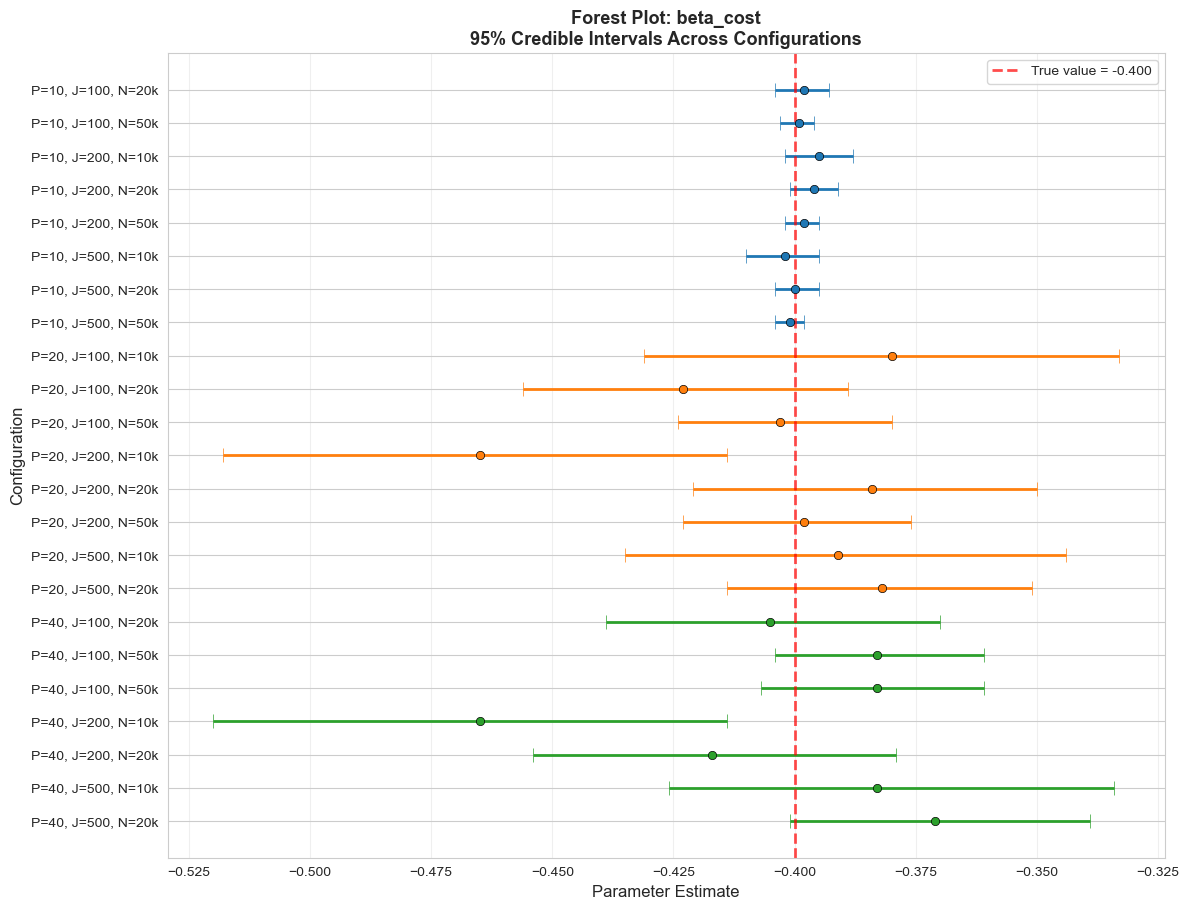

In [23]:
# Forest Plot: Parameter estimates with credible intervals across configurations
# Select parameter to visualize
parameter_to_plot = 'beta_cost'  # Change this to any parameter you want to visualize

param_data = df_metrics[df_metrics['parameter'] == parameter_to_plot].copy()
    
# Create configuration labels
param_data['config'] = param_data.apply(
    lambda row: f"P={row['P']}, J={row['J']}, N={row['N']//1000}k", axis=1
)

# Sort by P, J, N for better visualization
param_data = param_data.sort_values(['P', 'J', 'N'])

# Get true value for reference line
true_value = param_data['true_value'].iloc[0]

# Create figure
fig, ax = plt.subplots(figsize=(12, max(6, len(param_data) * 0.4)))

# Define colors for P values
colors = {10: 'C0', 20: 'C1', 40: 'C2'}
param_data['color'] = param_data['P'].map(colors)

# Plot error bars (credible intervals) - plot each point individually to handle colors
y_positions = range(len(param_data))
for idx, (_, row) in enumerate(param_data.iterrows()):
    ax.errorbar(
        row['posterior_mean'], 
        idx,
        xerr=[[row['posterior_mean'] - row['hdi_low']], 
              [row['hdi_high'] - row['posterior_mean']]],
        fmt='o',
        markersize=6,
        capsize=5,
        capthick=2,
        linewidth=2,
        ecolor=row['color'],
        markerfacecolor=row['color'],
        markeredgecolor='black',
        markeredgewidth=0.5
    )

# Add true value reference line
ax.axvline(true_value, color='red', linestyle='--', linewidth=2, 
           label=f'True value = {true_value:.3f}', alpha=0.7)

# Customize plot
ax.set_yticks(y_positions)
ax.set_yticklabels(param_data['config'])
ax.set_xlabel('Parameter Estimate', fontsize=12)
ax.set_ylabel('Configuration', fontsize=12)
ax.set_title(f'Forest Plot: {parameter_to_plot}\n95% Credible Intervals Across Configurations', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, axis='x')

# Invert y-axis so first config is at top
ax.invert_yaxis()

plt.tight_layout()
# plt.savefig(f'/Users/preto/Documents/EPFL/PhD/projects/Bayesian/bayesian-choice-modeling-w-alt-sampling/results/results_pymc/forest_plot_{parameter_to_plot}.pdf')
plt.show()

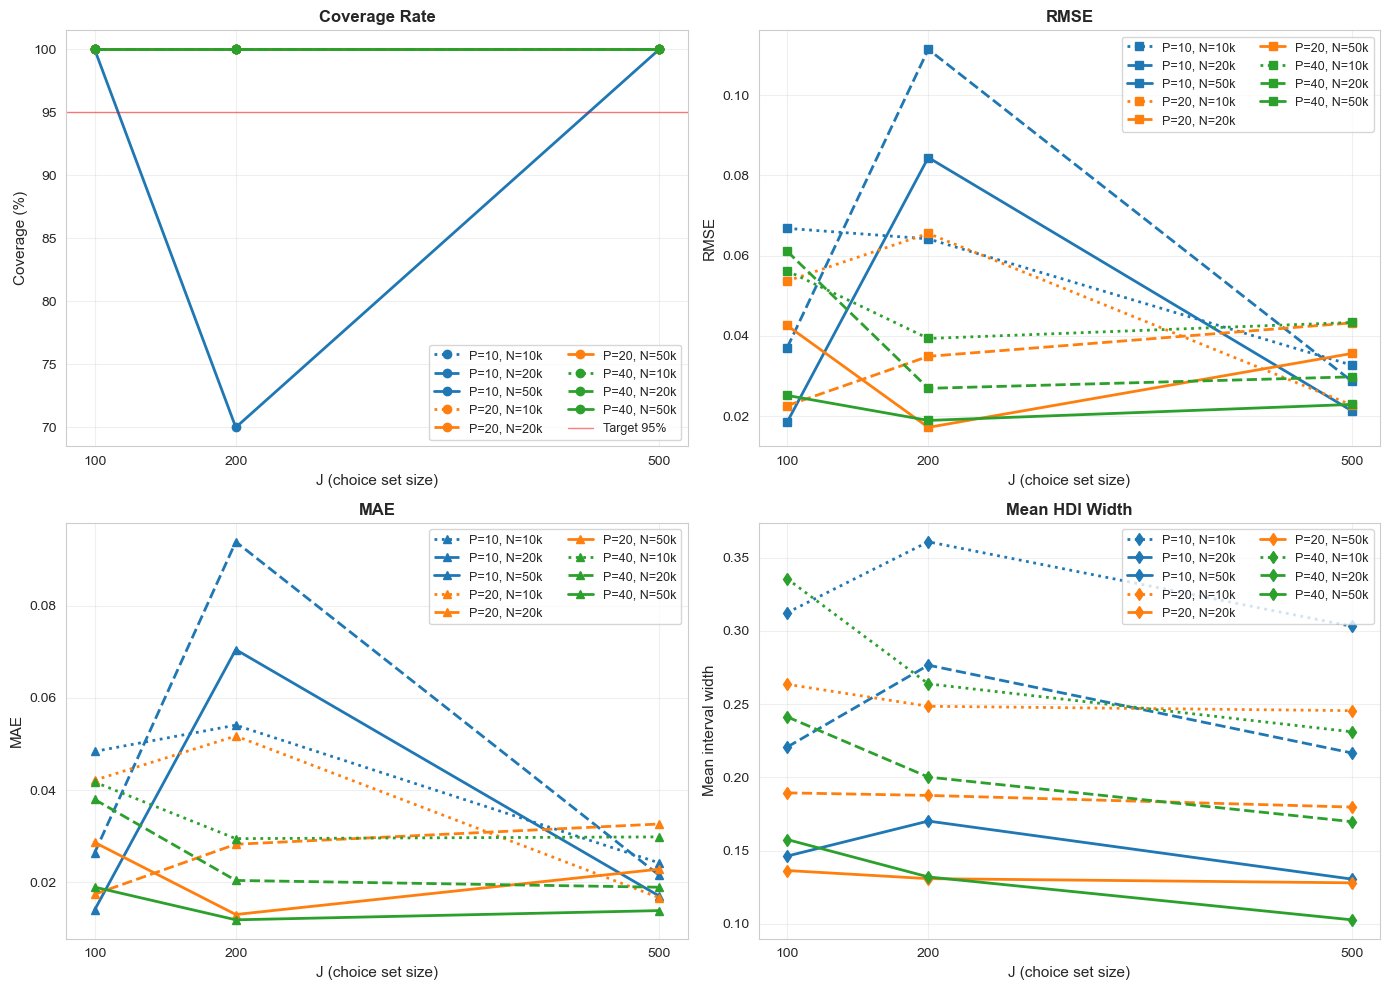

In [18]:
if not agg.empty:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Coverage by J, with P as curves and N as line styles
    ax = axes[0, 0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['coverage_pct'], 
                   marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(95, color='red', linestyle='-', linewidth=1, label='Target 95%', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Coverage (%)', fontsize=11)
    ax.set_title('Coverage Rate', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 2. RMSE by J, with P as curves and N as line styles
    ax = axes[0, 1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['rmse'], 
                   marker='s', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('RMSE', fontsize=11)
    ax.set_title('RMSE', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 3. MAE by J, with P as curves and N as line styles
    ax = axes[1, 0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['mae'], 
                   marker='^', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('MAE', fontsize=11)
    ax.set_title('MAE', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 4. Mean interval width by J, with P as curves and N as line styles
    ax = axes[1, 1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['mean_interval_width'], 
                   marker='d', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Mean interval width', fontsize=11)
    ax.set_title('Mean HDI Width', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()
else:
    print("No aggregated data to plot")

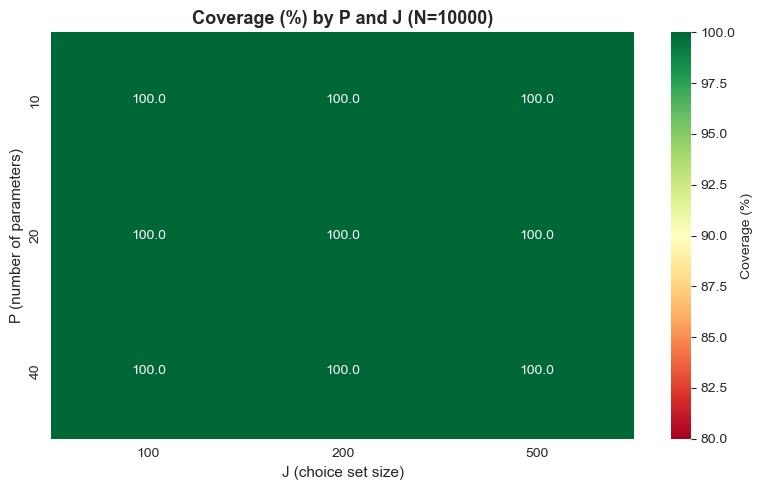

In [19]:
# Heatmap: Coverage by P and J (for largest N)
if not agg.empty:
    max_n = 10000
    sub = agg[agg['N'] == max_n].pivot(index='P', columns='J', values='coverage_pct')
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(sub, annot=True, fmt='.1f', cmap='RdYlGn', vmin=80, vmax=100, 
                cbar_kws={'label': 'Coverage (%)'}, ax=ax)
    ax.set_title(f'Coverage (%) by P and J (N={max_n})', fontsize=13, fontweight='bold')
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('P (number of parameters)', fontsize=11)
    plt.tight_layout()
    plt.show()

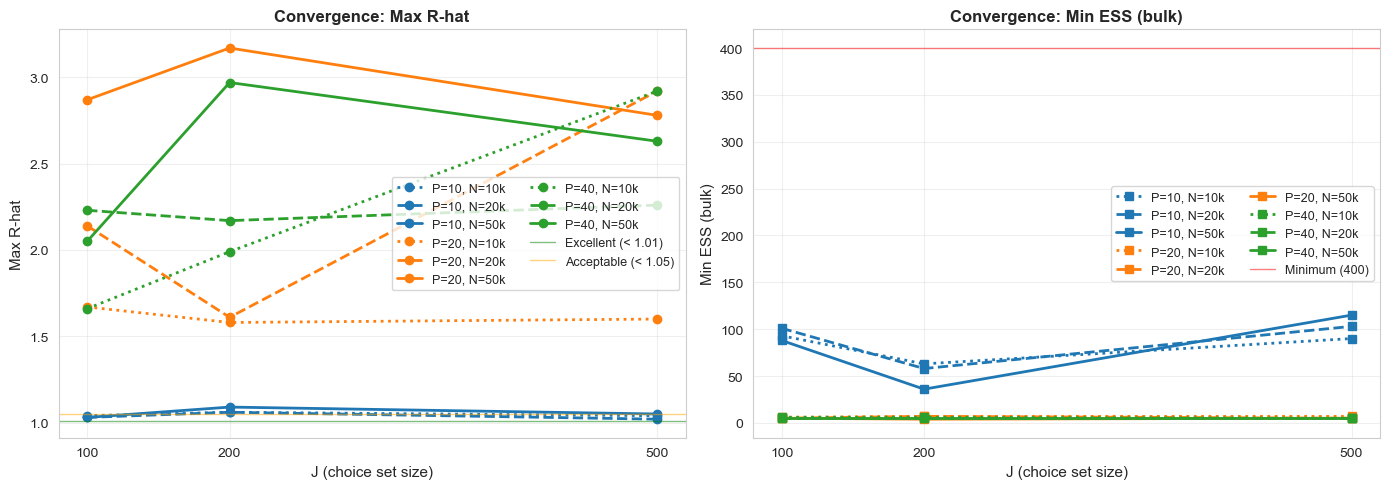

In [21]:
# Convergence diagnostics visualization
if not agg.empty and 'max_rhat' in agg.columns:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Max R-hat by J, with P as curves and N as line styles
    ax = axes[0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['max_rhat'], 
                   marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(1.01, color='green', linestyle='-', linewidth=1, label='Excellent (< 1.01)', alpha=0.5)
    ax.axhline(1.05, color='orange', linestyle='-', linewidth=1, label='Acceptable (< 1.05)', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Max R-hat', fontsize=11)
    ax.set_title('Convergence: Max R-hat', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 2. Min ESS (bulk) by J, with P as curves and N as line styles
    ax = axes[1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['min_ess_bulk'], 
                   marker='s', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(400, color='red', linestyle='-', linewidth=1, label='Minimum (400)', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Min ESS (bulk)', fontsize=11)
    ax.set_title('Convergence: Min ESS (bulk)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()

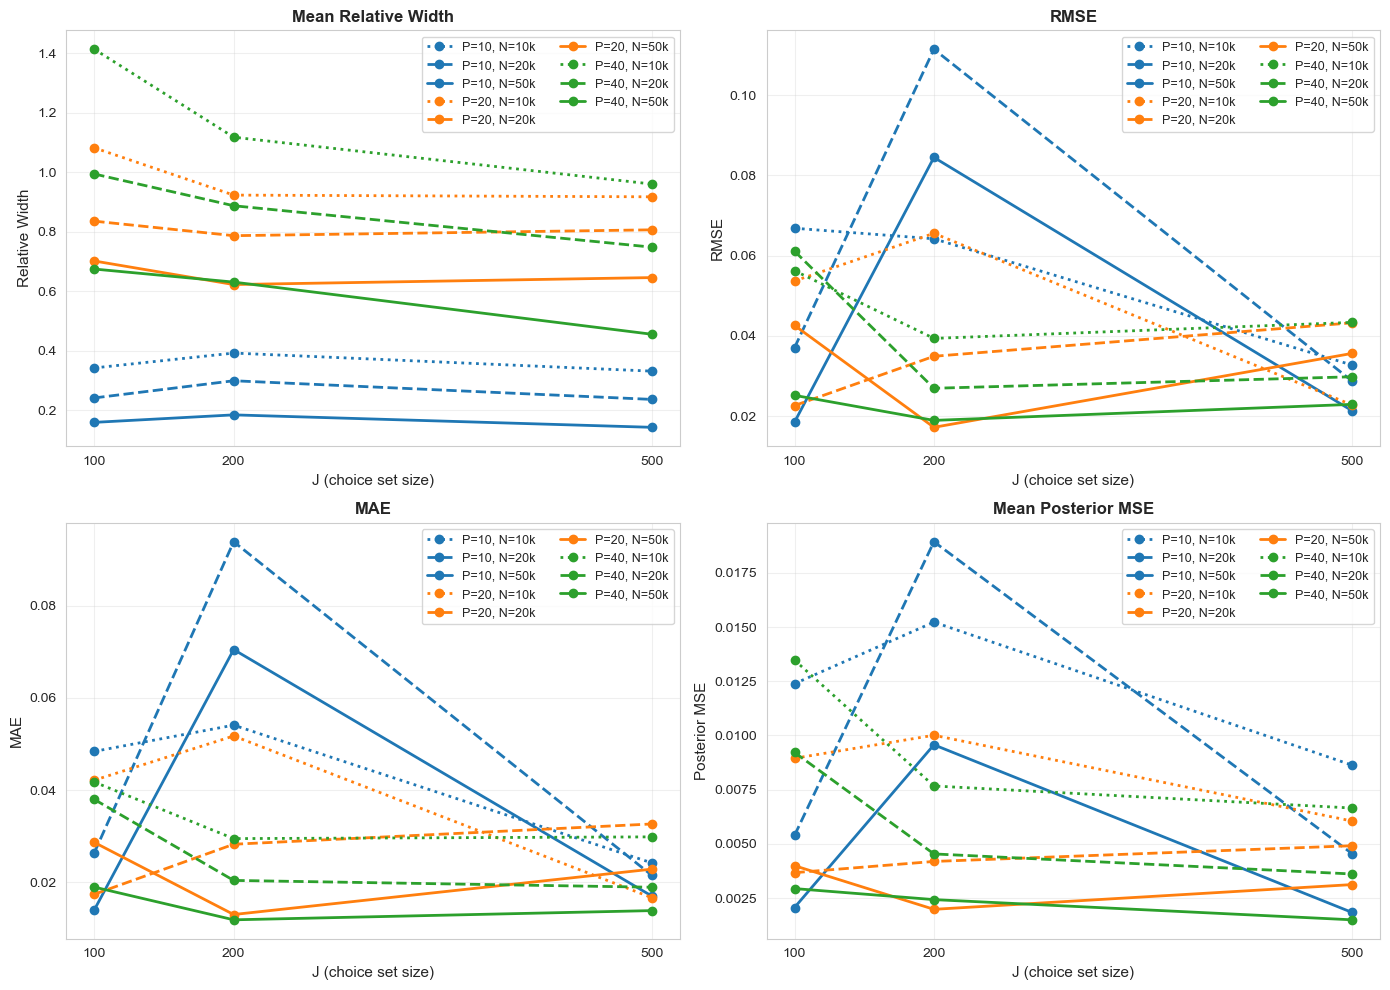

In [23]:
# Additional plots: Metrics by J (X-axis), with P as curves and N as line styles
if not agg.empty:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    # Metrics to plot
    metrics = [
        ('mean_relative_width', 'Mean Relative Width', 'Relative Width'),
        ('rmse', 'RMSE', 'RMSE'),
        ('mae', 'MAE', 'MAE'),
        ('mean_posterior_mse', 'Mean Posterior MSE', 'Posterior MSE')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric_col, metric_title, ylabel) in enumerate(metrics):
        ax = axes[idx]
        
        # Plot each combination of P and N
        for p_val in sorted(agg['P'].unique()):
            for n_val in sorted(agg['N'].unique()):
                data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
                ax.plot(data['J'], data[metric_col], 
                       marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                       label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2, markersize=6)
        
        ax.set_xlabel('J (choice set size)', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(metric_title, fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9, ncol=2)
        ax.grid(alpha=0.3)
        ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()
else:
    print("No aggregated data to plot")



## 6. Save Results to CSV

Save both dataframes for further analysis

In [ ]:
# Save DataFrame 1: All ArviZ summaries
if not df_summaries.empty:
    out_summaries = RESULTS_DIR / 'all_arviz_summaries.csv'
    # df_summaries.to_csv(out_summaries, index=False)
    print(f"✓ Saved all ArviZ summaries to: {out_summaries}")
    print(f"  Shape: {df_summaries.shape}")

# Save DataFrame 2: All quality indicators
if not df_metrics.empty:
    out_metrics = RESULTS_DIR / 'all_quality_indicators.csv'
    # df_metrics.to_csv(out_metrics, index=False)
    print(f"✓ Saved all quality indicators to: {out_metrics}")
    print(f"  Shape: {df_metrics.shape}")

# Save DataFrame 3: Convergence diagnostics
if not df_convergence.empty:
    out_convergence = RESULTS_DIR / 'convergence_diagnostics.csv'
    # df_convergence.to_csv(out_convergence, index=False)
    print(f"✓ Saved convergence diagnostics to: {out_convergence}")
    print(f"  Shape: {df_convergence.shape}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

✓ Saved all ArviZ summaries to: ../../results/all_arviz_summaries.csv
  Shape: (390, 14)
✓ Saved all quality indicators to: ../../results/all_quality_indicators.csv
  Shape: (390, 18)
✓ Saved convergence diagnostics to: ../../results/convergence_diagnostics.csv
  Shape: (18, 14)

ANALYSIS COMPLETE!
